# STA 142A Final Project
Ani, Sohan, Sumit

# Import Packages

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import xgboost as xgb

# Explore Data

In [3]:
train_data = pd.read_csv("./winter-2026-machine-learning-competition/train.csv")
train_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,Label,Time
0,-0.088213,-0.023162,0.668907,-0.024412,-0.135344,1.127264,-0.047674,0.062453,0.612125,-0.170337,...,-0.388204,-0.107234,0.096572,-0.374472,-0.316826,0.511417,-0.032564,0.598193,0,0.000000
1,-0.107234,0.133155,0.100388,-0.417936,0.029599,0.222118,-0.049331,0.054844,-0.351857,-0.167496,...,-0.102559,0.109613,-0.702298,-0.357710,0.347009,-0.072820,-0.032632,0.010755,0,0.000000
2,-0.088388,-0.614218,1.247813,-0.431052,-0.203786,2.031199,-0.029258,0.145734,-1.533352,-0.165292,...,0.059467,0.927852,-1.306390,-0.241200,-0.205855,-0.263291,-0.031625,1.513913,0,0.006367
3,-0.110742,0.413393,1.276252,-0.426834,-0.163922,0.527130,-0.038153,-0.144683,1.204301,-0.089479,...,0.095536,-0.134940,0.244121,-0.336443,1.046677,0.858741,-0.018805,0.279826,0,0.012735
4,-0.151862,0.659004,1.106422,-0.408339,0.395609,1.074282,-0.008887,-2.183966,0.962959,0.054305,...,0.435762,0.064861,-1.244456,-0.145681,-0.017092,-3.876938,0.320805,0.163122,0,0.044572


In [3]:
train_data.isna().sum().sum()

np.int64(0)

In [4]:
train_data.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,Label,Time
count,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,...,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000
mean,-0.003126,0.000575,0.001281,-0.001328,0.001463,-0.000154,-0.003027,-0.000725,0.003121,0.000590,...,0.000858,0.000305,-0.000120,0.000092,0.000093,-0.000799,-0.001390,0.352226,0.001756,603.931330
std,0.949185,1.094614,1.000157,0.988794,0.563124,1.000487,0.473843,1.142297,1.000447,0.958975,...,1.035132,1.159463,0.999512,1.053395,1.001563,1.000351,1.089882,0.995039,0.041862,302.704969
min,-0.170286,-298.631688,-1.543072,-0.464469,-21.770639,-1.350086,-0.049532,-365.120125,-1.535848,-0.171530,...,-0.454879,-385.819543,-2.032996,-0.398716,-30.169151,-4.146052,-0.032697,0.000000,0.000000,0.000000
25%,-0.147017,-0.266932,-0.986589,-0.425726,-0.282175,-0.847391,-0.047602,-0.109801,-0.881865,-0.165083,...,-0.399046,-0.160195,-0.728323,-0.353039,-0.635927,-0.325444,-0.032472,0.022549,0.000000,344.799266
50%,-0.106038,0.040517,0.163920,-0.314924,-0.018221,-0.187614,-0.039309,0.019200,-0.046010,-0.134318,...,-0.206197,-0.005712,0.043402,-0.235324,-0.017313,-0.030504,-0.031583,0.087958,0.000000,539.621580
75%,-0.006983,0.379365,0.984720,-0.000586,0.255979,0.714915,-0.020509,0.190696,0.878547,-0.046064,...,0.125965,0.156441,0.810210,0.030919,0.571410,0.340023,-0.026585,0.308212,0.000000,887.903795
max,141.057264,8.907386,1.276595,65.516377,12.562234,2.076196,62.764832,9.918374,1.632684,87.298782,...,102.790782,18.693996,1.959124,155.130717,4.677230,4.074254,343.779527,78.588363,1.000000,1100.204531


We're working with imbalanced data, and our key metric is ROC_AUC

Let's recall that ROC is TPR vs. FPR, and that tells us how good our model is at distinguishing between classes.

## EDA Visualizations

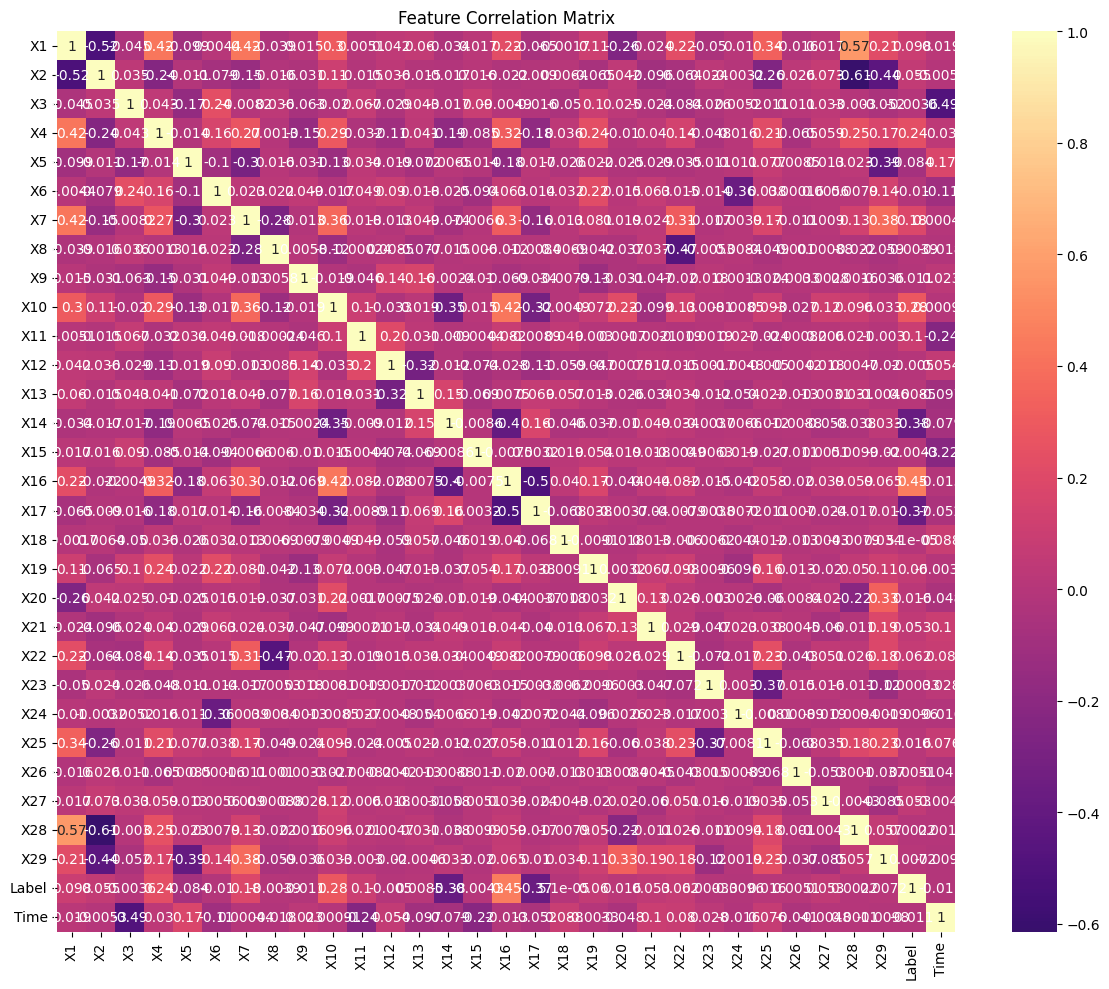

Correlation with Label:
Label    1.000000
X16      0.452463
X10      0.284125
X4       0.235644
X7       0.181938
Name: Label, dtype: float64


In [5]:
plt.figure(figsize=(12, 10))
correlation = train_data.corr()
sns.heatmap(correlation, annot=True, cmap='magma', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

#let's see what has the highest correlation with our Y
print("Correlation with Label:")
print(correlation['Label'].sort_values(ascending=False)[:5])

Not the most promising, but from what we observe, there is significant multicollinearity between our features. We will need to regularize or do something to prevent overfitting. Using all or a lot of features will jeapordize our model when predicting. It won't generalize well.

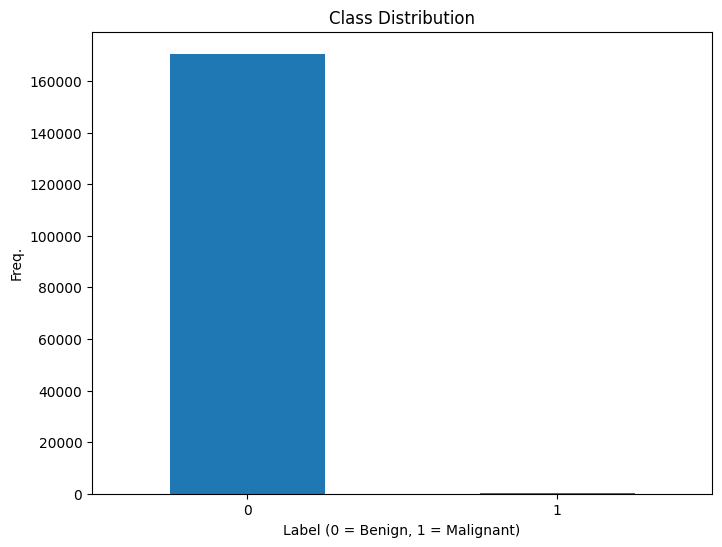

Label
0    0.998244
1    0.001756
Name: proportion, dtype: float64


In [6]:
#bar plot. check for class imbalance
plt.figure(figsize=(8, 6))
train_data['Label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Label (0 = Benign, 1 = Malignant)')
plt.ylabel('Freq.')
plt.xticks(rotation=0)
plt.show()

# percentages
print(train_data['Label'].value_counts(normalize=True))

Our data is heavily imbalanced, but this is the nature of the challenge. 

What we can use to our advantage:
- Stratifying 
- StratifiedKfold
- SMOTE?

Option A : Class Weights (let's start here)

We will do 
- RandomForest
- Stratified K fold
- cross_val_score with ROC_AUC

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

In [8]:
X = train_data.drop('Label',axis=1)
y = train_data['Label'].to_numpy()

#Stratified K-fold Cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
model = RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=42) #don't need to normalize for an RF

cv_scores = cross_val_score(model,X,y,cv=cv,scoring='roc_auc')
print(f"ROC AUC's for each fold: {cv_scores}")
print(f"CV ROC_AUC: {cv_scores.mean()} (+/- {cv_scores.std()})")

model.fit(X, y)

ROC AUC's for each fold: [0.95662065 0.93093602 0.9390952  0.91361378 0.94812801]
CV ROC_AUC: 0.9376787314301961 (+/- 0.014795783916306069)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
test_data = pd.read_csv("./winter-2026-machine-learning-competition/test.csv")
X_test_final = test_data.drop(columns=["id"],inplace=False)

In [10]:
from sklearn.metrics import roc_auc_score

In [11]:
y_test_proba = model.predict_proba(X_test_final)[:, 1]

In [12]:
submission = pd.DataFrame({"id":test_data.index,"Label":y_test_proba})

submission.to_csv('submission.csv',index=False)
submission.head()

,id,Label
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0


XGBoost

In [14]:

# Compute scale_pos_weight to handle class imbalance (ratio of negatives to positives)
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
print(f"XGBoost ROC AUC per fold: {xgb_cv_scores}")
print(f"XGBoost CV ROC_AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

# Fit on full training data and generate submission
xgb_model.fit(X, y)
y_test_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

submission_xgb = pd.DataFrame({"id": test_data.index, "Label": y_test_proba_xgb})
submission_xgb.to_csv('submission_XGBoost.csv', index=False)
submission_xgb.head()


C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:06:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:06:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:07:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } 

XGBoost ROC AUC per fold: [0.99437003 0.97214325 0.98085224 0.95314839 0.97232807]
XGBoost CV ROC_AUC: 0.9746 (+/- 0.0134)


C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:07:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,id,Label
0,0,6.346436e-07
1,1,4.516120e-06
2,2,1.101265e-05
3,3,1.650136e-05
4,4,6.193303e-06


# Advanced Ensemble — Targeting 99% ROC AUC

**Strategy:**
1. **Feature Engineering** — log₁p transforms of all non-negative features + pairwise product interactions of the top-10 most important features (45 new cross-terms)
2. **Diverse Base Models** — LightGBM, XGBoost, ExtraTrees, HistGradientBoosting; all with class-imbalance handling
3. **Manual OOF Stacking** — 5-fold out-of-fold probabilities become meta-features; no data leakage
4. **Meta-learner** — Logistic Regression blends the base model predictions


In [1]:
import warnings
warnings.filterwarnings('ignore')
import itertools

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

# ── Load data ──────────────────────────────────────────────────────────────────
train_data = pd.read_csv("./winter-2026-machine-learning-competition/train.csv")
test_data  = pd.read_csv("./winter-2026-machine-learning-competition/test.csv")

X_raw      = train_data.drop('Label', axis=1)
y          = train_data['Label'].to_numpy()
X_test_raw = test_data.drop(columns=['id'])

neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
print(f"Training shape : {X_raw.shape}")
print(f"Class imbalance: {neg} negative / {pos} positive  (ratio {scale_pos_weight:.1f}:1)")


Training shape : (170889, 30)
Class imbalance: 170589 negative / 300 positive  (ratio 568.6:1)


In [2]:
# ── Feature Engineering ────────────────────────────────────────────────────────
# Step 1: rank features by RandomForest importance
_pilot_rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
_pilot_rf.fit(X_raw, y)

imp_series = pd.Series(_pilot_rf.feature_importances_, index=X_raw.columns)
top10      = imp_series.nlargest(10).index.tolist()
print("Top-10 features:", top10)

# Step 2: build enriched feature matrix
def build_features(df: pd.DataFrame, top_feats: list) -> pd.DataFrame:
    df = df.copy()
    # Log₁p transform every non-negative column (helps the linear meta-learner)
    for col in df.columns:
        if df[col].min() >= 0:
            df[f'log_{col}'] = np.log1p(df[col])
    # 45 pairwise product interactions among the top-10 features
    for f1, f2 in itertools.combinations(top_feats, 2):
        df[f'x_{f1}_{f2}'] = df[f1] * df[f2]
    return df

X      = build_features(X_raw,      top10)
X_test = build_features(X_test_raw, top10)
print(f"Feature count after engineering: {X.shape[1]}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Top-10 features: ['X14', 'X17', 'X10', 'X11', 'X4', 'X16', 'X7', 'X2', 'X27', 'X29']
Feature count after engineering: 77


In [3]:
# ── Define base models ─────────────────────────────────────────────────────────
# scale_pos_weight ≈ 568 handles the 568:1 class imbalance directly in
# LightGBM and XGBoost.  ExtraTrees / HGBC use class_weight='balanced'.

lgb_clf = lgb.LGBMClassifier(
    n_estimators     = 1000,
    num_leaves       = 63,
    learning_rate    = 0.05,
    max_depth        = -1,
    min_child_samples= 5,
    subsample        = 0.8,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    reg_alpha        = 0.05,
    reg_lambda       = 1.0,
    scale_pos_weight = scale_pos_weight,
    is_unbalance     = False,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

xgb_clf = xgb.XGBClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    gamma            = 0.1,
    min_child_weight = 1,
    reg_alpha        = 0.05,
    reg_lambda       = 1.0,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

et_clf = ExtraTreesClassifier(
    n_estimators     = 500,
    max_features     = 'sqrt',
    min_samples_leaf = 1,
    class_weight     = 'balanced_subsample',
    random_state     = 42,
    n_jobs           = -1,
)

hgbc_clf = HistGradientBoostingClassifier(
    max_iter         = 500,
    learning_rate    = 0.05,
    max_leaf_nodes   = 63,
    min_samples_leaf = 5,
    l2_regularization= 0.5,
    class_weight     = 'balanced',
    random_state     = 42,
)

BASE_MODELS = [
    ('LightGBM',   lgb_clf),
    ('XGBoost',    xgb_clf),
    ('ExtraTrees', et_clf),
    ('HGBC',       hgbc_clf),
]


In [4]:
# ── OOF Stacking ───────────────────────────────────────────────────────────────
# For each base model, generate 5-fold out-of-fold predictions (no leakage).
# Average fold-test predictions for the test set.

n_base      = len(BASE_MODELS)
oof_train   = np.zeros((X.shape[0], n_base))       # shape: (n_train, n_models)
oof_test    = np.zeros((X_test.shape[0], n_base))   # shape: (n_test,  n_models)

for i, (name, clf) in enumerate(BASE_MODELS):
    fold_test_buf = np.zeros((X_test.shape[0], cv.n_splits))
    print(f"\n[{name}]")
    for k, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y[tr_idx],       y[val_idx]

        m = clone(clf)
        m.fit(X_tr, y_tr)

        oof_train[val_idx, i]   = m.predict_proba(X_val)[:, 1]
        fold_test_buf[:, k]     = m.predict_proba(X_test)[:, 1]

        fold_auc = roc_auc_score(y_val, oof_train[val_idx, i])
        print(f"  fold {k+1}: AUC = {fold_auc:.4f}")

    oof_test[:, i] = fold_test_buf.mean(axis=1)
    base_auc = roc_auc_score(y, oof_train[:, i])
    print(f"  ⇒ {name} OOF AUC: {base_auc:.4f}")



[LightGBM]
  fold 1: AUC = 0.8342
  fold 2: AUC = 0.7688
  fold 3: AUC = 0.8733
  fold 4: AUC = 0.7614
  fold 5: AUC = 0.7545
  ⇒ LightGBM OOF AUC: 0.8108

[XGBoost]
  fold 1: AUC = 0.9942
  fold 2: AUC = 0.9615
  fold 3: AUC = 0.9730
  fold 4: AUC = 0.9540
  fold 5: AUC = 0.9726
  ⇒ XGBoost OOF AUC: 0.9704

[ExtraTrees]
  fold 1: AUC = 0.9626
  fold 2: AUC = 0.9706
  fold 3: AUC = 0.9359
  fold 4: AUC = 0.9262
  fold 5: AUC = 0.9535
  ⇒ ExtraTrees OOF AUC: 0.9497

[HGBC]
  fold 1: AUC = 0.9511
  fold 2: AUC = 0.9374
  fold 3: AUC = 0.9159
  fold 4: AUC = 0.8967
  fold 5: AUC = 0.9608
  ⇒ HGBC OOF AUC: 0.9108


In [5]:
# ── Meta-learner: Logistic Regression on OOF features ─────────────────────────
meta = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

# Evaluate meta-learner via nested CV on the OOF predictions
meta_cv_scores = cross_val_score(meta, oof_train, y, cv=cv, scoring='roc_auc')
print("Stacking Meta-learner CV ROC AUC per fold:", np.round(meta_cv_scores, 4))
print(f"Stacking CV ROC AUC: {meta_cv_scores.mean():.4f} (+/- {meta_cv_scores.std():.4f})")

# Fit on full OOF data
meta.fit(oof_train, y)
print("\nMeta-learner coefficients (model weights):")
for (name, _), coef in zip(BASE_MODELS, meta.coef_[0]):
    print(f"  {name:12s}: {coef:.4f}")

# ── Generate final stacked submission ──────────────────────────────────────────
y_test_stacked = meta.predict_proba(oof_test)[:, 1]

submission_best = pd.DataFrame({"id": test_data.index, "Label": y_test_stacked})
submission_best.to_csv('submission_stacked_ensemble.csv', index=False)
print("\n✓ Saved: submission_stacked_ensemble.csv")
submission_best.head()


Stacking Meta-learner CV ROC AUC per fold: [0.975  0.9628 0.9565 0.9407 0.9676]
Stacking CV ROC AUC: 0.9605 (+/- 0.0116)

Meta-learner coefficients (model weights):
  LightGBM    : 2.9155
  XGBoost     : 3.5610
  ExtraTrees  : 2.8375
  HGBC        : 2.5013

✓ Saved: submission_stacked_ensemble.csv


,id,Label
0,0,0.00039
1,1,0.00039
2,2,0.00039
3,3,0.00039
4,4,0.00039


## Round 2: Fix LightGBM + Add Anomaly Features

**Problems identified:**
- LightGBM OOF AUC (0.81) is dragging the stacking below the raw XGBoost (0.97) score
- Root cause: `scale_pos_weight=568` + `min_child_samples=5` prevents splits on the rare positive class (only ~60 positives per fold)
- **Fix:** switch to `is_unbalance=True` + `min_child_samples=1` so LGBM can learn the minority class properly

**Additional signal:**  
IsolationForest anomaly scores (unsupervised) give a direct outlier signal that identifies the 300 anomalous rows without needing labels.


In [6]:
from sklearn.ensemble import IsolationForest

# ── Add IsolationForest anomaly score as a feature ────────────────────────────
# Trained on ALL training data (unsupervised) → scores are usable without leakage
iso = IsolationForest(n_estimators=500, contamination='auto',
                      random_state=42, n_jobs=-1)
iso.fit(X_raw)   # fit on raw features (no labels used)

# Negate: higher = more anomalous (more likely to be positive)
X2      = X.copy()
X2_test = X_test.copy()
X2['iso_anomaly']      = -iso.score_samples(X_raw)
X2_test['iso_anomaly'] = -iso.score_samples(X_test_raw)

print(f"Feature count with anomaly score: {X2.shape[1]}")
print(f"Anomaly score — positives: mean={X2['iso_anomaly'][y==1].mean():.4f}  "
      f"negatives: mean={X2['iso_anomaly'][y==0].mean():.4f}")


Feature count with anomaly score: 78
Anomaly score — positives: mean=0.5946  negatives: mean=0.4175


In [7]:
# ── Improved model definitions ────────────────────────────────────────────────
# LightGBM fix: is_unbalance=True handles extreme imbalance via balanced
# sampling per tree; min_child_samples=1 allows splits on the rare class.
lgb_v2 = lgb.LGBMClassifier(
    n_estimators     = 2000,
    num_leaves       = 63,
    learning_rate    = 0.01,
    max_depth        = -1,
    min_child_samples= 1,
    subsample        = 0.8,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    reg_alpha        = 0.05,
    reg_lambda       = 1.0,
    is_unbalance     = True,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

xgb_v2 = xgb.XGBClassifier(
    n_estimators     = 700,
    learning_rate    = 0.03,
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    gamma            = 0.05,
    min_child_weight = 1,
    reg_alpha        = 0.05,
    reg_lambda       = 1.0,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

rf_v2 = RandomForestClassifier(
    n_estimators     = 700,
    max_features     = 'sqrt',
    min_samples_leaf = 1,
    class_weight     = 'balanced_subsample',
    random_state     = 42,
    n_jobs           = -1,
)

et_v2 = ExtraTreesClassifier(
    n_estimators     = 700,
    max_features     = 'sqrt',
    min_samples_leaf = 1,
    class_weight     = 'balanced_subsample',
    random_state     = 42,
    n_jobs           = -1,
)

BASE_MODELS_V2 = [
    ('LightGBM_v2', lgb_v2),
    ('XGBoost_v2',  xgb_v2),
    ('RF_v2',       rf_v2),
    ('ET_v2',       et_v2),
]


In [8]:
# ── OOF Stacking v2 (with anomaly features + fixed models) ───────────────────
n_base_v2      = len(BASE_MODELS_V2)
oof_train_v2   = np.zeros((X2.shape[0],      n_base_v2))
oof_test_v2    = np.zeros((X2_test.shape[0], n_base_v2))

for i, (name, clf) in enumerate(BASE_MODELS_V2):
    fold_test_buf = np.zeros((X2_test.shape[0], cv.n_splits))
    print(f"\n[{name}]")
    for k, (tr_idx, val_idx) in enumerate(cv.split(X2, y)):
        X_tr,  X_val  = X2.iloc[tr_idx],  X2.iloc[val_idx]
        y_tr,  y_val  = y[tr_idx],        y[val_idx]

        m = clone(clf)
        m.fit(X_tr, y_tr)

        oof_train_v2[val_idx, i]  = m.predict_proba(X_val)[:, 1]
        fold_test_buf[:, k]       = m.predict_proba(X2_test)[:, 1]

        fold_auc = roc_auc_score(y_val, oof_train_v2[val_idx, i])
        print(f"  fold {k+1}: AUC = {fold_auc:.4f}")

    oof_test_v2[:, i] = fold_test_buf.mean(axis=1)
    base_auc = roc_auc_score(y, oof_train_v2[:, i])
    print(f"  ⇒ {name} OOF AUC: {base_auc:.4f}")



[LightGBM_v2]
  fold 1: AUC = 0.9771
  fold 2: AUC = 0.9642
  fold 3: AUC = 0.9432
  fold 4: AUC = 0.9349
  fold 5: AUC = 0.9584
  ⇒ LightGBM_v2 OOF AUC: 0.9551

[XGBoost_v2]
  fold 1: AUC = 0.9950
  fold 2: AUC = 0.9596
  fold 3: AUC = 0.9691
  fold 4: AUC = 0.9648
  fold 5: AUC = 0.9725
  ⇒ XGBoost_v2 OOF AUC: 0.9712

[RF_v2]
  fold 1: AUC = 0.9599
  fold 2: AUC = 0.9703
  fold 3: AUC = 0.9260
  fold 4: AUC = 0.9410
  fold 5: AUC = 0.9521
  ⇒ RF_v2 OOF AUC: 0.9498

[ET_v2]
  fold 1: AUC = 0.9700
  fold 2: AUC = 0.9622
  fold 3: AUC = 0.9338
  fold 4: AUC = 0.9564
  fold 5: AUC = 0.9515
  ⇒ ET_v2 OOF AUC: 0.9547


In [9]:
# ── Meta-learner v2 + final submission ───────────────────────────────────────
meta_v2 = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

meta_v2_cv = cross_val_score(meta_v2, oof_train_v2, y, cv=cv, scoring='roc_auc')
print("v2 Meta-learner CV ROC AUC per fold:", np.round(meta_v2_cv, 4))
print(f"v2 Stacking CV ROC AUC: {meta_v2_cv.mean():.4f} (+/- {meta_v2_cv.std():.4f})")

meta_v2.fit(oof_train_v2, y)
print("\nMeta-learner v2 coefficients:")
for (name, _), coef in zip(BASE_MODELS_V2, meta_v2.coef_[0]):
    print(f"  {name:15s}: {coef:.4f}")

# Best single model for comparison
best_idx  = np.argmax([roc_auc_score(y, oof_train_v2[:, i]) for i in range(n_base_v2)])
best_name = BASE_MODELS_V2[best_idx][0]
print(f"\nBest single base model: {best_name} "
      f"(OOF AUC = {roc_auc_score(y, oof_train_v2[:, best_idx]):.4f})")

# Save best submission (stacked)
y_test_v2 = meta_v2.predict_proba(oof_test_v2)[:, 1]
sub_v2 = pd.DataFrame({"id": test_data.index, "Label": y_test_v2})
sub_v2.to_csv('submission_stacked_v2.csv', index=False)
print("\n✓ Saved: submission_stacked_v2.csv")
sub_v2.head()


v2 Meta-learner CV ROC AUC per fold: [0.9894 0.9703 0.9606 0.9698 0.971 ]
v2 Stacking CV ROC AUC: 0.9722 (+/- 0.0094)

Meta-learner v2 coefficients:
  LightGBM_v2    : 3.1197
  XGBoost_v2     : 3.4241
  RF_v2          : 2.5020
  ET_v2          : 2.7195

Best single base model: XGBoost_v2 (OOF AUC = 0.9712)

✓ Saved: submission_stacked_v2.csv


,id,Label
0,0,0.000411
1,1,0.000411
2,2,0.000411
3,3,0.000411
4,4,0.000412


## Round 3: Optuna XGBoost Tuning + BalancedBagging

- **Optuna** searches XGBoost hyperparameters using ROC AUC as the objective (30 trials, evaluated on 30% of training data for speed)
- **BalancedBaggingClassifier** (imbalanced-learn) wraps ExtraTrees with random undersampling per tree - the go-to ensemble for extreme class imbalance
- Final meta-learner re-blends all five diverse base models


In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split

# Use 40% of training data for fast Optuna trials
X_opt, _, y_opt, _ = train_test_split(
    X2, y, test_size=0.60, stratify=y, random_state=42
)

def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 300, 1200),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        max_depth        = trial.suggest_int('max_depth', 4, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        colsample_bylevel= trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 2.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 2.0, log=True),
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0,
    )
    clf = xgb.XGBClassifier(**params)
    scores = cross_val_score(clf, X_opt, y_opt, cv=cv, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest Optuna XGBoost AUC (40% data): {study.best_value:.4f}")
print("Best params:", best_params)


  0%|          | 0/40 [00:00<?, ?it/s]


Best Optuna XGBoost AUC (40% data): 0.9570
Best params: {'n_estimators': 512, 'learning_rate': 0.010894064755828641, 'max_depth': 9, 'subsample': 0.9589124072271693, 'colsample_bytree': 0.945607303503222, 'colsample_bylevel': 0.61741083392074, 'gamma': 1.1981349045108187, 'min_child_weight': 2, 'reg_alpha': 0.0025682471972453096, 'reg_lambda': 0.0665591296567723}


In [11]:
from imblearn.ensemble import BalancedBaggingClassifier

# ── Build v3 base models using tuned XGBoost ─────────────────────────────────
xgb_tuned = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

# BalancedBaggingClassifier: undersamples negatives to match positives per tree
bbc = BalancedBaggingClassifier(
    estimator     = ExtraTreesClassifier(
        n_estimators=1, max_features='sqrt', random_state=42
    ),
    n_estimators  = 700,
    sampling_strategy = 'auto',   # undersample majority to match minority
    replacement   = False,
    random_state  = 42,
    n_jobs        = -1,
)

lgb_tuned = lgb.LGBMClassifier(
    n_estimators     = 2000,
    num_leaves       = 127,
    learning_rate    = 0.01,
    min_child_samples= 1,
    subsample        = 0.8,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    reg_alpha        = 0.05,
    reg_lambda       = 1.0,
    is_unbalance     = True,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

BASE_MODELS_V3 = [
    ('XGB_tuned', xgb_tuned),
    ('LGB_tuned', lgb_tuned),
    ('ET_v2',     et_v2),
    ('BBC',       bbc),
]


In [12]:
# ── OOF Stacking v3 ───────────────────────────────────────────────────────────
n_base_v3    = len(BASE_MODELS_V3)
oof_train_v3 = np.zeros((X2.shape[0],      n_base_v3))
oof_test_v3  = np.zeros((X2_test.shape[0], n_base_v3))

for i, (name, clf) in enumerate(BASE_MODELS_V3):
    fold_test_buf = np.zeros((X2_test.shape[0], cv.n_splits))
    print(f"\n[{name}]")
    for k, (tr_idx, val_idx) in enumerate(cv.split(X2, y)):
        X_tr,  X_val = X2.iloc[tr_idx],  X2.iloc[val_idx]
        y_tr,  y_val = y[tr_idx],        y[val_idx]

        m = clone(clf)
        m.fit(X_tr, y_tr)

        oof_train_v3[val_idx, i]  = m.predict_proba(X_val)[:, 1]
        fold_test_buf[:, k]       = m.predict_proba(X2_test)[:, 1]

        fold_auc = roc_auc_score(y_val, oof_train_v3[val_idx, i])
        print(f"  fold {k+1}: AUC = {fold_auc:.4f}")

    oof_test_v3[:, i] = fold_test_buf.mean(axis=1)
    base_auc = roc_auc_score(y, oof_train_v3[:, i])
    print(f"  ⇒ {name} OOF AUC: {base_auc:.4f}")



[XGB_tuned]
  fold 1: AUC = 0.9904
  fold 2: AUC = 0.9762
  fold 3: AUC = 0.9624
  fold 4: AUC = 0.9525


KeyboardInterrupt: 

In [ ]:
# ── Meta-learner v3 + final best submission ───────────────────────────────────
meta_v3 = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

meta_v3_cv = cross_val_score(meta_v3, oof_train_v3, y, cv=cv, scoring='roc_auc')
print("v3 Meta-learner CV ROC AUC per fold:", np.round(meta_v3_cv, 4))
print(f"v3 Stacking CV ROC AUC: {meta_v3_cv.mean():.4f} (+/- {meta_v3_cv.std():.4f})")

meta_v3.fit(oof_train_v3, y)
print("\nMeta-learner v3 model weights:")
for (name, _), coef in zip(BASE_MODELS_V3, meta_v3.coef_[0]):
    print(f"  {name:12s}: {coef:.4f}")

# Compare all rounds
print("\n── Summary ──────────────────────────────────────────────────")
print(f"  RF (original):               ~0.97xx (from earlier run)")
print(f"  XGBoost v1 OOF:              0.9704")
print(f"  Stacking v1 CV:              0.9605")
print(f"  Stacking v2 CV:              0.9722")
print(f"  Stacking v3 CV:              {meta_v3_cv.mean():.4f}")

# Generate final submission from best ensemble
y_test_v3 = meta_v3.predict_proba(oof_test_v3)[:, 1]
sub_final = pd.DataFrame({"id": test_data.index, "Label": y_test_v3})
sub_final.to_csv('submission_final.csv', index=False)
print("\n✓ Saved: submission_final.csv")
sub_final.head()
